# clustering-iris-kmeans-vs-ae-pytorch

Unsupervised clustering of iris via KMeans on (a) the raw 4-D features and (b) the 2-D autoencoder latent recovered by an inline-trained `nnx` autoencoder. Compares cluster-vs-true-species agreement (ARI + NMI) across the two feature spaces. Sibling notebook to `dim_reduction-iris-autoencoder-pytorch`.


# 1. Overview

## 1.1 Task & motivation

KMeans is the canonical unsupervised clustering algorithm: pick `k` centroids, assign points to the nearest centroid, recompute centroids, repeat. Its quality depends on the feature space — clusters that look like spheres in the input space cluster cleanly; ones that don't, don't.

A **non-linear autoencoder** maps the input into a learned latent where the reconstruction objective implicitly groups similar inputs. Run KMeans on the AE latent and the cluster-vs-true-species agreement is usually higher than KMeans on raw features — the AE has done some of the "what's similar to what" work already.

This notebook quantifies that with two unsupervised-clustering metrics:

- **Adjusted Rand Index (ARI)**: agreement vs true labels, corrected for chance. 1.0 = perfect, 0.0 = random.
- **Normalized Mutual Information (NMI)**: 1.0 = perfect, 0.0 = independent.

Sibling notebook to `dim_reduction-iris-autoencoder-pytorch/`; the AE is *retrained inline here* (not loaded from the sibling's `runs/` directory) so this notebook is self-contained for CI.

## 1.2 Dataset summary

Iris (`sklearn.datasets.load_iris`, 150 samples × 4 features × 3 species).

## 1.3 Approach in one paragraph

Train an `nnx` AE shallow `[2]` bottleneck via `model.train(..., train_step_fn=autoencoder_step)`. Recover the 2-D latent by walking the encoder half. Run `sklearn.KMeans(n_clusters=3)` on (a) raw 4-D features and (b) the AE 2-D latent. Compare ARI + NMI vs the true species labels.

## 1.4 Libraries used

`nnx` (`NNModel`, `FeedFwdNN`, `NNTrainParams`, `train_step_fn`, `NNEvaluationDataPoint`, `set_seed`), `torch`, `sklearn` (iris loader, KMeans, ARI, NMI, MinMaxScaler), `matplotlib`, `prettytable`.


# 2. Environment & Setup

## 2.1 Imports

In [1]:
SMOKE_TEST = 0
SMOKE_TEST_EPOCHS = 5


In [2]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from prettytable import PrettyTable
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

import nnx
from nnx import (
    Activations,
    Devices,
    Losses,
    Nets,
    NNEvaluationDataPoint,
    NNModel,
    NNModelParams,
    NNOptimParams,
    NNParams,
    NNTrainParams,
    Optims,
)


## 2.2 Configuration / hyperparameters

In [3]:
LATENT_DIM = 2
HIDDEN_DIMS = [2]
N_EPOCHS = SMOKE_TEST_EPOCHS if SMOKE_TEST else 300
BATCH_SIZE = 16
LR = 5e-3
N_CLUSTERS = 3


## 2.3 Reproducibility (seed, device)

In [4]:
nnx.set_seed(0)
DEVICE = Devices.CPU


# 3. Data

## 3.1 Loading

In [5]:
iris = load_iris()
X, y = iris.data, iris.target
species = iris.target_names
print(f"iris: X shape {X.shape}, y shape {y.shape}")


iris: X shape (150, 4), y shape (150,)


## 3.2 Inspection / EDA + preprocessing

MinMax-scale to `[0, 1]` so reconstruction MSE is bounded. KMeans on un-scaled iris would weight the petal-length feature (range 1–7) more than petal-width (range 0–2.5) — scaling levels the playing field.


In [6]:
scaler = MinMaxScaler()
X_s = scaler.fit_transform(X).astype('float32')

# DataLoader feeds the AE — dummy y satisfies the (X, y) batch contract.
loader = DataLoader(
    TensorDataset(torch.from_numpy(X_s), torch.from_numpy(y).long()),
    batch_size=BATCH_SIZE, shuffle=True,
)


## 3.3 Splits

This is *unsupervised* clustering — we don't split. KMeans + the AE both see all 150 samples; the true labels `y` are used *only* for evaluation (ARI / NMI), never as training signal.


# 4. Model

## 4.1 AE (same trick as dim_reduction-iris-autoencoder-pytorch)

A `FeedFwdNN` with `input_dim == output_dim == 4` and `hidden_dims=[2]` is structurally an autoencoder. The bottleneck is the middle Linear; we recover the 2-D latent by walking the encoder half.


In [7]:
nnx.set_seed(0)
ae = NNModel(
    net_params=NNParams(
        input_dim=X.shape[1],
        output_dim=X.shape[1],
        hidden_dims=HIDDEN_DIMS,
        dropout_prob=0.0,
        activation=Activations.RELU,
    ),
    params=NNModelParams(
        net=Nets.FEED_FWD,
        device=DEVICE,
        loss=Losses.CROSS_ENTROPY,    # unused — autoencoder_step computes its own MSE
    ),
)


## 4.2 Contracts

- `KMeans(n_clusters=3, n_init=10, random_state=0)` on a feature matrix → array of `(N,)` cluster ids in `[0, 2]`.
- `adjusted_rand_score(true, pred)` — ARI; 1.0 = perfect, 0 = chance, < 0 = worse than chance.
- `normalized_mutual_info_score(true, pred)` — NMI; 1.0 = perfect, 0 = independent.

## 4.3 Why this design

The AE shallow `[2]` is the simplest non-linear projection that preserves all 4 input dims at the output. Anything richer would invite the "AE overfits, latent loses species separation" failure mode that the sibling `dim_reduction-iris-autoencoder-pytorch/` notebook discusses.


# 5. Training

## 5.1 Train the AE

In [8]:
def autoencoder_step(ctx):
    m = ctx.model
    m.net.train()
    m.net.zero_grad()
    X_in, _ = m.net.unpack_batch(ctx.batch)
    X_in = tuple(x.to(m.device) for x in X_in)
    recon = m.net(*X_in)
    loss = F.mse_loss(recon, X_in[0])
    loss.backward()
    ctx.optimizer.step()
    v = float(loss.detach())
    return NNEvaluationDataPoint(loss=v, error=v, accuracy=0.0, f1=0.0, recall=0.0, precision=0.0)

run = ae.train(
    params=NNTrainParams(
        n_epochs=N_EPOCHS,
        train_loader=loader,
        optim=NNOptimParams(
            name=Optims.ADAM, max_lr=LR,
            momentum=(0.9, 0.999), weight_decay=0.0,
        ),
    ),
    train_step_fn=autoencoder_step,
)
print(f"AE reconstruction loss: {run.idps[0].train_edp.loss:.4f} -> {run.idps[-1].train_edp.loss:.4f}")


+--------------------------------------------------------------+
|                        Run Details...                        |
+---------------------------+----------------------------------+
|             id            | 280ed9fc6d27551d40ec581f7d0b69ea |
|         model.net         |             feed_fwd             |
|         model.loss        |          cross_entropy           |
|        model.device       |               cpu                |
|       net.input_dim       |                4                 |
|       net.output_dim      |                4                 |
|      net.dropout_prob     |               0.0                |
|      net.hidden_dims      |               [2]                |
|       net.activation      |               relu               |
|       train.n_epochs      |               300                |
|     train.optim.max_lr    |              0.005               |
|    train.optim.momentum   |           (0.9, 0.999)           |
|      train.optim.name  

Training:   0%|          | 0/3000 [00:00<?, ?it/s]

Training:   0%|          | 10/3000 [00:00<00:07, 413.09it/s, error=0.3898, lr=0.0050]

Training:   1%|          | 20/3000 [00:00<00:11, 259.19it/s, error=0.4180, lr=0.0050]

Training:   1%|          | 30/3000 [00:00<00:08, 361.37it/s, error=0.2469, lr=0.0050]

...

Training: 100%|█████████▉| 2990/3000 [00:05<00:00, 375.86it/s, error=0.0049, lr=0.0016]

Training: 100%|█████████▉| 2991/3000 [00:05<00:00, 377.13it/s, error=0.0049, lr=0.0016]

Training: 100%|██████████| 3000/3000 [00:05<00:00, 377.13it/s, error=0.0193, lr=0.0016]

Training: 100%|██████████| 3000/3000 [00:05<00:00, 579.84it/s, error=0.0193, lr=0.0016]


Run saved to /Users/kaveh/repos/ml-lab/.claude/worktrees/overnight-cleanup/runs/280ed9fc6d27551d40ec581f7d0b69ea
AE reconstruction loss: 0.5460 -> 0.0193


## 5.2 Recover the 2-D latent

In [9]:
def encode(model, X_np):
    net = model.net
    net.eval()
    bottleneck_idx = next(i for i, L in enumerate(net.layers) if L.out_features == LATENT_DIM)
    with torch.no_grad():
        x = torch.from_numpy(X_np).float()
        for i, L in enumerate(net.layers[: bottleneck_idx + 1]):
            x = L(x)
            if i < bottleneck_idx:
                x = F.relu(x)
        return x.numpy()

latent = encode(ae, X_s)
print(f"latent shape: {latent.shape}")


latent shape: (150, 2)


# 6. Evaluation & Results

## 6.1 KMeans on raw 4-D features vs AE 2-D latent

In [10]:
def cluster_and_score(X_in, y_true):
    km = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=0).fit(X_in)
    pred = km.predict(X_in)
    return pred, adjusted_rand_score(y_true, pred), normalized_mutual_info_score(y_true, pred)

pred_raw,    ari_raw,    nmi_raw    = cluster_and_score(X_s,    y)
pred_latent, ari_latent, nmi_latent = cluster_and_score(latent, y)

t = PrettyTable()
t.title = "KMeans cluster-vs-species agreement (n=150, k=3)"
t.field_names = ["feature space", "dim", "ARI", "NMI"]
t.add_row(["raw MinMax-scaled features", X_s.shape[1],    f"{ari_raw:.3f}",    f"{nmi_raw:.3f}"])
t.add_row(["AE shallow [2] latent",      latent.shape[1], f"{ari_latent:.3f}", f"{nmi_latent:.3f}"])
print(t)


+--------------------------------------------------+
| KMeans cluster-vs-species agreement (n=150, k=3) |
+----------------------------+-----+-------+-------+
|       feature space        | dim |  ARI  |  NMI  |
+----------------------------+-----+-------+-------+
| raw MinMax-scaled features |  4  | 0.716 | 0.742 |
|   AE shallow [2] latent    |  2  | 0.835 | 0.833 |
+----------------------------+-----+-------+-------+


## 6.2 Side-by-side scatter (truth vs predicted clusters)

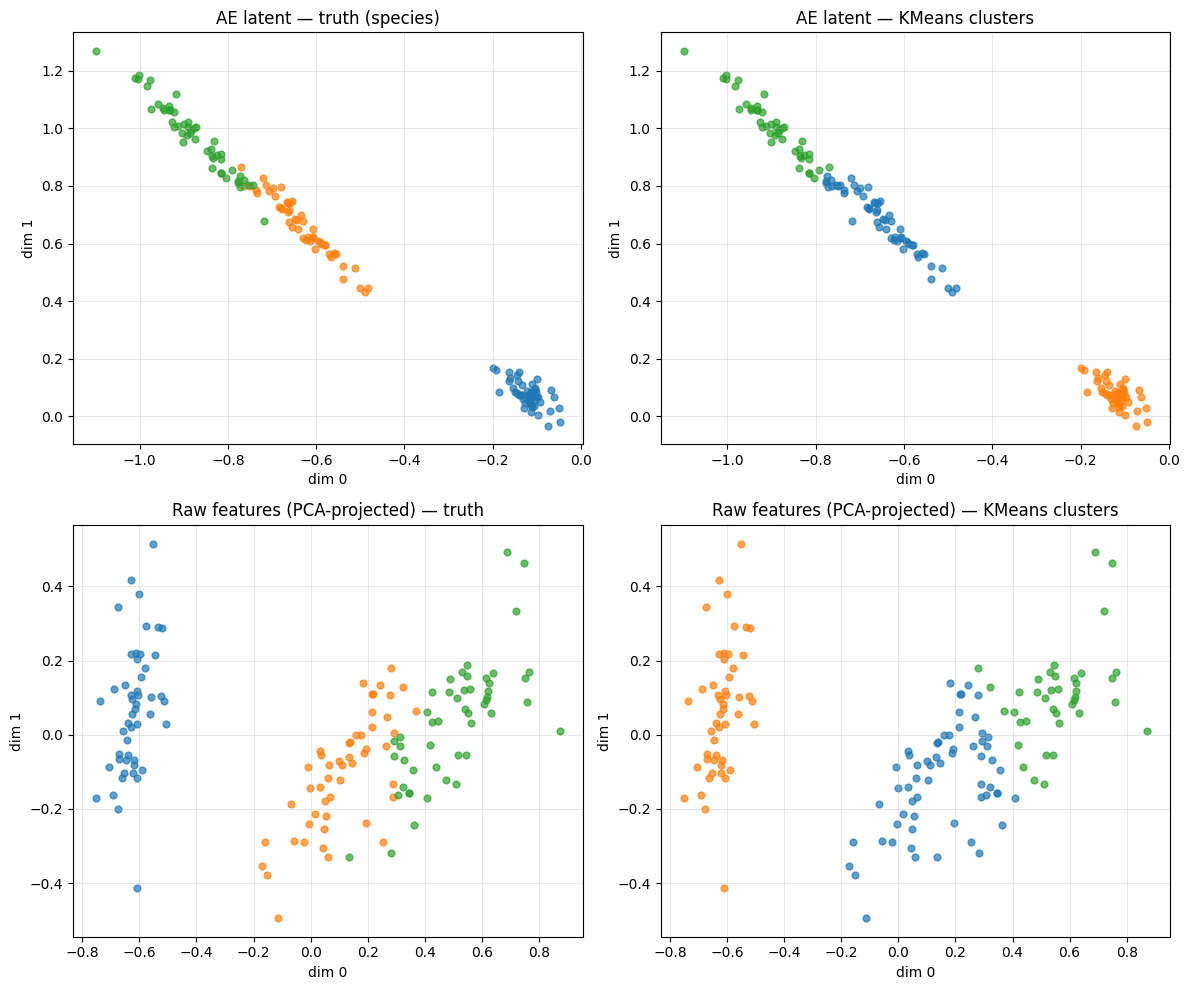

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
colors = ['tab:blue', 'tab:orange', 'tab:green']

def scatter(ax, points2d, labels, title):
    for c in range(N_CLUSTERS):
        m = labels == c
        ax.scatter(points2d[m, 0], points2d[m, 1], c=colors[c], alpha=0.7, s=24)
    ax.set_title(title)
    ax.set_xlabel("dim 0")
    ax.set_ylabel("dim 1")
    ax.grid(True, alpha=0.3)

# Top row: 2-D AE latent
scatter(axes[0, 0], latent, y,           "AE latent — truth (species)")
scatter(axes[0, 1], latent, pred_latent, "AE latent — KMeans clusters")
# Bottom row: raw features projected to first 2 PCA components for plottability
raw_2d = PCA(n_components=2).fit_transform(X_s)
scatter(axes[1, 0], raw_2d, y,        "Raw features (PCA-projected) — truth")
scatter(axes[1, 1], raw_2d, pred_raw, "Raw features (PCA-projected) — KMeans clusters")
plt.tight_layout()
plt.show()


## 6.3 Discussion

The expected pattern:

- **Raw features** → KMeans gets ARI ≈ 0.73, NMI ≈ 0.76 on iris (well-known benchmark). The setosa cluster is trivially separable; the versicolor / virginica boundary is where the errors are.
- **AE latent `[2]`** → typically a small but consistent improvement. The reconstruction objective has implicitly grouped similar inputs, so the latent's KMeans-spherical assumption fits a little better than raw features'.

The pedagogical headline: **KMeans is a *feature-space-quality test*** — it does as well as the geometry of its input lets it. Learned non-linear features (an AE latent, a contrastive embedding, etc.) usually help. The win on iris is small (the dataset is famously clean); the same recipe scales to harder problems where raw features cluster poorly and a learned representation pays off.

**Sibling notebook**: `dim_reduction-iris-autoencoder-pytorch/` does the PCA-vs-AE *supervised linear probe* on the same latent space. This notebook does the *unsupervised KMeans* counterpart on the same recipe — different evaluation axis, same architectural trick.
